# Gap Junction Detection — Metrics Pipeline

This notebook performs two **separate** analyses on the `631_bat_gj_2024` dataset:

1. **Detection-source agreement** — IoU-based matching between *raw model inference* and the *human-corrected reference*, on a per-image basis. This section quantifies model/correction effects only and is **not used for biological conclusions**.
2. **Awake-vs-sleep biological comparison** — using *human-corrected detections only*: counts, bounding-box area, and per-Z-stack depth trends, compared between the `awake_*` and `sleep_*` recordings.

> **Terminology note:** the two detection sources live in folders named `session_171_default-session` and `session_172_231_model` on disk. Per the project convention, this notebook maps them once to functional labels (`human_corrected` / `raw_model`) in the CONFIG cell below, and every printed table, plot, and markdown note from that point on uses only the functional labels — the session_* names are never used in Methods/Results-style output.


## 1. Imports


In [78]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)


## 2. Configuration

Edit the paths/constants below for your local setup. This is the **only** place the raw session folder names appear.


In [79]:
# ============================================================
# CONFIGURATION — edit these for your local setup
# ============================================================

REPO_ROOT = Path(r"./").resolve()
DATA_ROOT = REPO_ROOT / "data"
ROOT_DIR = DATA_ROOT if DATA_ROOT.exists() else REPO_ROOT
OUTPUT_DIR = REPO_ROOT / "results"  # where to save plots, tables, etc.
OUTPUT_DIR.mkdir(exist_ok=True)

# Map the two detection-source session folder names to FUNCTIONAL labels.
# Everything downstream (tables, plots, markdown text) uses ONLY these labels.
SESSION_FOLDER_TO_LABEL = {
    "corrected_by_operator": "human_corrected",
    "raw_inference": "raw_model",
}

# Friendlier display names used in plot titles/legends
LABEL_DISPLAY = {
    "human_corrected": "Human-corrected detections",
    "raw_model": "Raw model inference",
}

IOU_MATCH_THRESHOLD = 0.5  # IoU threshold for counting a raw-model box as a true-positive match

# Each subfolder is an INDEPENDENT recording (confirmed: sleep_2, sleep_2_1, sleep_2_2,
# sleep_2_3 are separate recordings, not chunks of one session), so the replicate group
# is simply the subfolder name itself -> no merging.

# Pulls the Z-stack index out of filenames like 40670_cx43_Z05_bbox.json
Z_INDEX_PATTERN = re.compile(r"_Z(\d+)", re.IGNORECASE)


In [80]:
# ! pip install nbdime  -i https://pypi.tuna.tsinghua.edu.cn/simple
! nbdime config-git --enable

## 3. File discovery

Walks `ROOT_DIR/<subfolder>/Detection/<session_folder>/*.json` and tags every file with subfolder, awake/sleep condition, replicate group, and functional session label.


In [81]:
def discover_json_files(root_dir: Path):
    records = []
    for subfolder in sorted(p for p in root_dir.iterdir() if p.is_dir()):
        detection_dir = subfolder / "Detection"
        if not detection_dir.exists():
            continue
        for session_dir in sorted(p for p in detection_dir.iterdir() if p.is_dir()):
            session_label = SESSION_FOLDER_TO_LABEL.get(session_dir.name)
            if session_label is None:
                print(f"  [warn] Unrecognized session folder, skipping: {session_dir}")
                continue
            for jf in sorted(session_dir.glob("*.json")):
                records.append({
                    "subfolder": subfolder.name,
                    "session_folder": session_dir.name,
                    "session_label": session_label,
                    "filepath": jf,
                })
    return records


def get_condition(subfolder_name: str) -> str:
    if subfolder_name.startswith("awake"):
        return "awake"
    elif subfolder_name.startswith("sleep"):
        return "sleep"
    return "unknown"


def get_replicate_group(subfolder_name: str) -> str:
    # Each subfolder is its own independent replicate group (no merging).
    return subfolder_name


def get_z_index(image_name: str):
    m = Z_INDEX_PATTERN.search(image_name or "")
    return int(m.group(1)) if m else np.nan


file_records = discover_json_files(ROOT_DIR)
print(f"Discovered {len(file_records)} JSON files across "
      f"{len({r['subfolder'] for r in file_records})} subfolders.")


Discovered 1460 JSON files across 13 subfolders.


## 4. Parsing

Each JSON file is parsed into two tidy tables:

- **`images_df`** — one row per image per session, *including images with zero `gap_junction` detections* (needed for correct density/zero-count handling).
- **`detections_df`** — one row per individual `gap_junction` bounding box, with `area = bbox_width × bbox_height` and `z_index` parsed from the filename.


In [82]:
def parse_detection_file(record):
    with open(record["filepath"], "r", encoding="utf-8") as f:
        data = json.load(f)

    det_rows, image_rows = [], []
    for image_key, detections in data.items():
        image_name = detections[0]["image_name"] if detections else image_key
        image_width = detections[0].get("image_width", np.nan) if detections else np.nan
        image_height = detections[0].get("image_height", np.nan) if detections else np.nan

        image_rows.append({
            "subfolder": record["subfolder"],
            "condition": get_condition(record["subfolder"]),
            "replicate_group": get_replicate_group(record["subfolder"]),
            "session_label": record["session_label"],
            "image_key": image_key,
            "image_name": image_name,
            "z_index": get_z_index(image_name),
            "image_width": image_width,
            "image_height": image_height,
            "n_detections": sum(1 for d in detections if d.get("label_name") == "gap_junction"),
        })

        for det in detections:
            if det.get("label_name") != "gap_junction":
                continue
            bbox_w, bbox_h = det.get("bbox_width", np.nan), det.get("bbox_height", np.nan)
            det_rows.append({
                "subfolder": record["subfolder"],
                "condition": get_condition(record["subfolder"]),
                "replicate_group": get_replicate_group(record["subfolder"]),
                "session_label": record["session_label"],
                "image_key": image_key,
                "image_name": image_name,
                "z_index": get_z_index(image_name),
                "bbox_x": det.get("bbox_x", np.nan),
                "bbox_y": det.get("bbox_y", np.nan),
                "bbox_width": bbox_w,
                "bbox_height": bbox_h,
                "area": (bbox_w * bbox_h) if pd.notna(bbox_w) and pd.notna(bbox_h) else np.nan,
                "image_width": det.get("image_width", np.nan),
                "image_height": det.get("image_height", np.nan),
                "score": det.get("score", np.nan),
            })
    return det_rows, image_rows


all_det_rows, all_image_rows = [], []
for rec in file_records:
    d, im = parse_detection_file(rec)
    all_det_rows.extend(d)
    all_image_rows.extend(im)

detections_df = pd.DataFrame(all_det_rows)
images_df = pd.DataFrame(all_image_rows)

print(f"Total gap_junction detections parsed: {len(detections_df):,}")
print(f"Total image entries (incl. zero-detection images): {len(images_df):,}")
detections_df.head()


Total gap_junction detections parsed: 263,020
Total image entries (incl. zero-detection images): 1,460


,subfolder,condition,replicate_group,session_label,image_key,image_name,z_index,bbox_x,bbox_y,bbox_width,bbox_height,area,image_width,image_height,score
0,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,1116.00,304.25,17.0,12.75,216.750,1707,1017,0.846680
1,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,451.25,298.00,15.5,12.50,193.750,1707,1017,0.826172
2,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,1242.00,367.25,15.0,11.75,176.250,1707,1017,0.811035
3,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,798.00,392.00,14.5,11.75,170.375,1707,1017,0.790527
4,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,836.50,425.25,16.0,11.75,188.000,1707,1017,0.790039


## 5. Sanity checks

Before computing any metric, confirm coverage is sane: image counts per subfolder/session, and any images present in only one detection source (these will be excluded from IoU matching in Section 6).


In [83]:
image_counts = (
    images_df.groupby(["subfolder", "condition", "session_label"])["image_key"]
    .nunique()
    .reset_index(name="n_images")
)
display(image_counts.pivot_table(index=["condition", "subfolder"],
                                  columns="session_label", values="n_images"))

mismatch_report = []
for subfolder, sub_df in images_df.groupby("subfolder"):
    keys_by_session = sub_df.groupby("session_label")["image_key"].apply(set).to_dict()
    labels = list(SESSION_FOLDER_TO_LABEL.values())
    if len(labels) == 2 and all(l in keys_by_session for l in labels):
        only_a = keys_by_session[labels[0]] - keys_by_session[labels[1]]
        only_b = keys_by_session[labels[1]] - keys_by_session[labels[0]]
        if only_a or only_b:
            mismatch_report.append((subfolder, labels[0], len(only_a), labels[1], len(only_b)))

if mismatch_report:
    print("Images present in only one detection source (excluded from IoU matching):")
    for row in mismatch_report:
        print(f"  {row[0]}: only-in-{row[1]}={row[2]}, only-in-{row[3]}={row[4]}")
else:
    print("All images have entries from both detection sources.")


session_label        human_corrected  raw_model
condition subfolder                            
awake     awake_1               50.0       50.0
          awake_2               55.0       55.0
          awake_3               39.0       39.0
          awake_4               64.0       64.0
          awake_5               71.0       71.0
          awake_6               33.0       33.0
sleep     sleep_1               46.0       46.0
          sleep_2               57.0       57.0
          sleep_2_1             72.0       72.0
          sleep_2_2             30.0       30.0
          sleep_2_3             78.0       78.0
          sleep_3               52.0       52.0
          sleep_4               83.0       83.0

All images have entries from both detection sources.


## 6. Section 1 — Detection-source agreement (raw model inference vs. human-corrected reference)

**Purpose:** quantify how much the raw automated model output differs from the human-corrected reference, using IoU-based box matching (precision / recall / F1, treating human-corrected as ground truth). This section describes detection/correction quality only.

> **This section must not be used to draw biological awake-vs-sleep conclusions.** It answers "how good is the raw model", not "do gap junctions differ between states".


In [84]:
def compute_iou(box_a, box_b):
    """box = (x, y, w, h)"""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    inter_x1, inter_y1 = max(ax, bx), max(ay, by)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = aw * ah + bw * bh - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def match_detections(ref_boxes, test_boxes, iou_threshold=IOU_MATCH_THRESHOLD):
    """
    Greedy one-to-one matching: each test (raw_model) box matched to at most one
    reference (human_corrected) box, maximizing IoU, above iou_threshold.
    Returns: tp, fp, fn, matched_ious
    """
    if not ref_boxes or not test_boxes:
        return 0, len(test_boxes), len(ref_boxes), []

    pairs = []
    for i, rb in enumerate(ref_boxes):
        for j, tb in enumerate(test_boxes):
            iou = compute_iou(rb, tb)
            if iou >= iou_threshold:
                pairs.append((iou, i, j))
    pairs.sort(reverse=True)

    used_ref, used_test, matched_ious = set(), set(), []
    for iou, i, j in pairs:
        if i in used_ref or j in used_test:
            continue
        used_ref.add(i)
        used_test.add(j)
        matched_ious.append(iou)

    tp = len(matched_ious)
    fp = len(test_boxes) - len(used_test)
    fn = len(ref_boxes) - len(used_ref)
    return tp, fp, fn, matched_ious


In [85]:
REF_LABEL, TEST_LABEL = "human_corrected", "raw_model"
BOX_COLS = ["bbox_x", "bbox_y", "bbox_width", "bbox_height"]

per_image_rows = []
for (subfolder, condition, image_key), g in detections_df.groupby(["subfolder", "condition", "image_key"]):
    ref_boxes = list(g.loc[g.session_label == REF_LABEL, BOX_COLS].itertuples(index=False, name=None))
    test_boxes = list(g.loc[g.session_label == TEST_LABEL, BOX_COLS].itertuples(index=False, name=None))
    if not ref_boxes and not test_boxes:
        continue
    tp, fp, fn, ious = match_detections(ref_boxes, test_boxes)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)
          if precision and recall and (precision + recall) > 0 else np.nan)
    per_image_rows.append({
        "subfolder": subfolder, "condition": condition, "image_key": image_key,
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "f1": f1,
        "mean_matched_iou": np.mean(ious) if ious else np.nan,
        "n_ref": len(ref_boxes), "n_test": len(test_boxes),
    })

detection_compare_df = pd.DataFrame(per_image_rows)
detection_compare_df.head()


,subfolder,condition,image_key,tp,fp,fn,precision,recall,f1,mean_matched_iou,n_ref,n_test
0,awake_1,awake,40521_cx43_Z00,73,22,0,0.768421,1.000000,0.869048,0.864614,73,95
1,awake_1,awake,40522_cx43_Z01,74,36,0,0.672727,1.000000,0.804348,0.857317,74,110
2,awake_1,awake,40523_cx43_Z02,75,27,4,0.735294,0.949367,0.828729,0.865138,79,102
3,awake_1,awake,40524_cx43_Z03,90,33,0,0.731707,1.000000,0.845070,0.865883,90,123
4,awake_1,awake,40525_cx43_Z04,91,27,1,0.771186,0.989130,0.866667,0.868064,92,118


In [86]:
def pooled_prf1(df):
    tp, fp, fn = df["tp"].sum(), df["fp"].sum(), df["fn"].sum()
    p = tp / (tp + fp) if (tp + fp) else np.nan
    r = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * p * r / (p + r) if p and r and (p + r) else np.nan
    return pd.Series({"precision": p, "recall": r, "f1": f1,
                       "mean_matched_iou": df["mean_matched_iou"].mean()})

print("Overall (pooled) agreement — raw model inference vs. human-corrected reference:")
display(pooled_prf1(detection_compare_df).to_frame("value"))

print("\nBy condition:")
display(detection_compare_df.groupby("condition").apply(pooled_prf1))

print("\nBy subfolder:")
display(detection_compare_df.groupby(["condition", "subfolder"]).apply(pooled_prf1))


Overall (pooled) agreement — raw model inference vs. human-corrected reference:


,value
precision,0.798250
recall,0.938586
f1,0.862748
mean_matched_iou,0.845050



By condition:


C:\Users\user\AppData\Local\Temp\ipykernel_176040\3924863616.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(detection_compare_df.groupby("condition").apply(pooled_prf1))


,precision,recall,f1,mean_matched_iou
condition,,,,
awake,0.710879,0.975900,0.822569,0.840666
sleep,0.829735,0.927635,0.875958,0.848508



By subfolder:


C:\Users\user\AppData\Local\Temp\ipykernel_176040\3924863616.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(detection_compare_df.groupby(["condition", "subfolder"]).apply(pooled_prf1))


precision    recall        f1  mean_matched_iou
condition subfolder                                                 
awake     awake_1     0.704494  0.970322  0.816312          0.854693
          awake_2     0.747429  0.986428  0.850456          0.846340
          awake_3     0.664995  0.924057  0.773408          0.834255
          awake_4     0.736509  0.981348  0.841481          0.836100
          awake_5     0.696255  0.991768  0.818145          0.830524
          awake_6     0.714811  0.995184  0.832012          0.844393
sleep     sleep_1     0.838135  0.926927  0.880298          0.837702
          sleep_2     0.871044  0.883180  0.877070          0.853853
          sleep_2_1   0.787247  0.972585  0.870156          0.831003
          sleep_2_2   0.799862  0.967616  0.875778          0.853574
          sleep_2_3   0.833333  0.928881  0.878517          0.839811
          sleep_3     0.793989  0.968670  0.872674          0.858675
          sleep_4     0.852158  0.902941  0.876815          0.862555

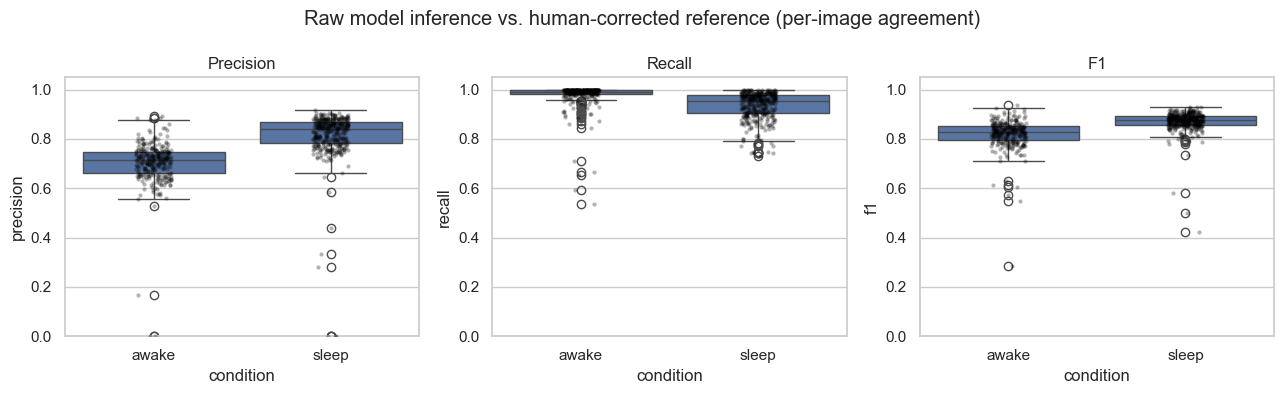

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    sns.boxplot(data=detection_compare_df, x="condition", y=metric, ax=ax)
    sns.stripplot(data=detection_compare_df, x="condition", y=metric, ax=ax,
                  color="black", alpha=0.3, size=3)
    ax.set_title(metric.capitalize())
    ax.set_ylim(0, 1.05)
fig.suptitle("Raw model inference vs. human-corrected reference (per-image agreement)")
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "detection_source_agreement.png", dpi=150)
plt.show()


In [88]:
print(detection_compare_df["condition"].unique())

['awake' 'sleep']


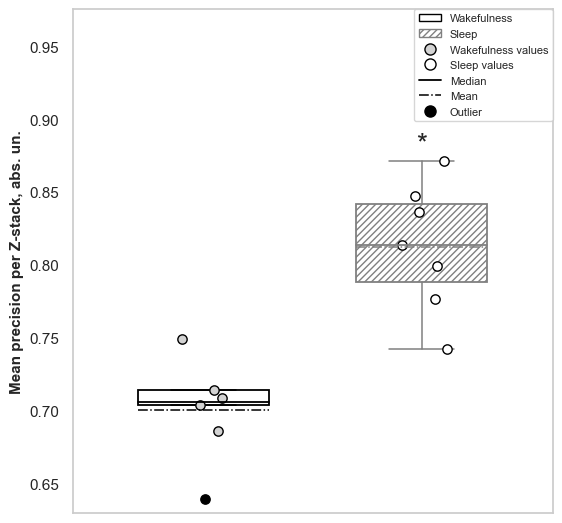

[PLOT] saved -> C:\Users\user\Downloads\Yandex_Downloads\631_bat_gj_2024\results\detection_agreement\zstack_precision.png (n_awake=6, n_sleep=7)


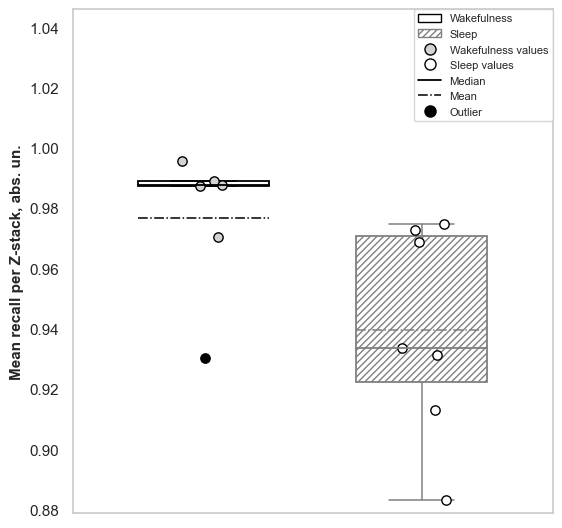

[PLOT] saved -> C:\Users\user\Downloads\Yandex_Downloads\631_bat_gj_2024\results\detection_agreement\zstack_recall.png (n_awake=6, n_sleep=7)


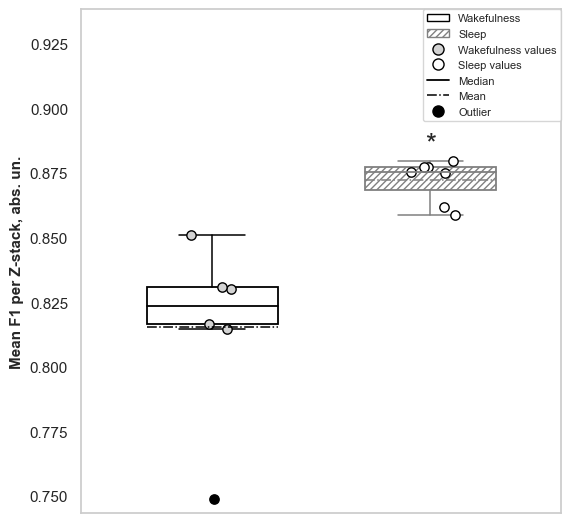

[PLOT] saved -> C:\Users\user\Downloads\Yandex_Downloads\631_bat_gj_2024\results\detection_agreement\zstack_f1.png (n_awake=6, n_sleep=7)


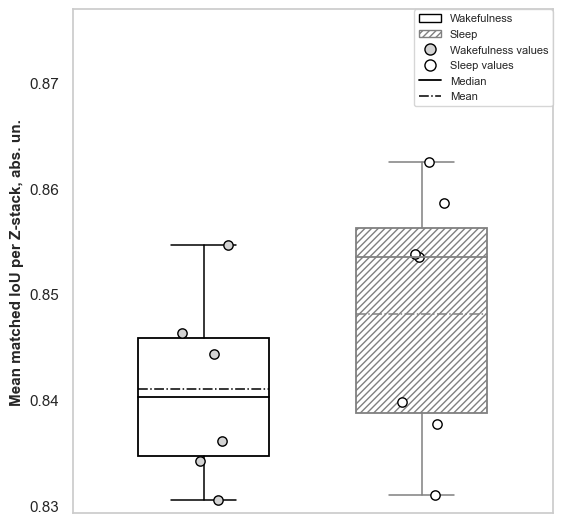

[PLOT] saved -> C:\Users\user\Downloads\Yandex_Downloads\631_bat_gj_2024\results\detection_agreement\zstack_mean_matched_iou.png (n_awake=6, n_sleep=7)


In [89]:
import statistics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


def iqr_outliers(values):
    vals = sorted(float(v) for v in values if v == v)
    if len(vals) < 4:
        return vals, []
    q1 = statistics.median(vals[: len(vals)//2])
    q3 = statistics.median(vals[(len(vals)+1)//2:])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    inliers  = [v for v in vals if lo <= v <= hi]
    outliers = [v for v in vals if v < lo or v > hi]
    return inliers, outliers


def _box_with_points(ax, left_vals, right_vals, ylabel, title, rng,
                      left_label="Wakefulness", right_label="Sleep"):
    if not left_vals and not right_vals:
        raise ValueError(
            f"Both '{left_label}' and '{right_label}' groups are empty — "
            f"check the subfolder/condition grouping used to build them."
        )

    left_in, left_out   = iqr_outliers(left_vals)
    right_in, right_out = iqr_outliers(right_vals)

    positions = [1, 2]
    box = ax.boxplot(
        [left_in if left_in else left_vals,
         right_in if right_in else right_vals],
        positions=positions, widths=0.6, showmeans=False, meanline=False,
        showfliers=False, patch_artist=True,
        medianprops=dict(linewidth=0),
        whiskerprops=dict(color="black", linewidth=1.1),
        capprops=dict(color="black", linewidth=1.1),
        boxprops=dict(color="black", linewidth=1.3),
    )

    box["boxes"][0].set_facecolor("white")
    box["boxes"][0].set_edgecolor("black")
    box["boxes"][1].set_facecolor("white")
    box["boxes"][1].set_edgecolor("gray")
    box["boxes"][1].set_hatch("/////")
    for part in ["whiskers", "caps"]:
        for i, line in enumerate(box[part]):
            if i >= len(box[part]) / 2:
                line.set_color("gray")

    box_half_width = 0.6 / 2
    for pos, vals, line_color in [(positions[0], left_vals, "black"),
                                   (positions[1], right_vals, "gray")]:
        if not vals:
            continue
        true_median = statistics.median(vals)
        true_mean   = statistics.mean(vals)
        x0, x1 = pos - box_half_width, pos + box_half_width
        ax.plot([x0, x1], [true_median, true_median],
                color=line_color, linewidth=1.3, linestyle="-", zorder=5)
        ax.plot([x0, x1], [true_mean, true_mean],
                color=line_color, linewidth=1.1, linestyle="-.", zorder=5)

    def jitter(values, center, width=0.12):
        values = np.asarray(values, dtype=float)
        return center + rng.uniform(-width, width, size=len(values))

    if left_in:
        ax.scatter(jitter(left_in, positions[0]), left_in,
                   facecolor="lightgray", edgecolor="black", s=45, zorder=3,
                   label=f"{left_label} values")
    if right_in:
        ax.scatter(jitter(right_in, positions[1]), right_in,
                   facecolor="white", edgecolor="black", s=45, zorder=3,
                   label=f"{right_label} values")

    have_outliers = bool(left_out) or bool(right_out)
    if left_out:
        ax.scatter(jitter(left_out, positions[0], width=0.03), left_out,
                   facecolor="black", edgecolor="black", s=45, zorder=4,
                   label="Outlier")
    if right_out:
        ax.scatter(jitter(right_out, positions[1], width=0.03), right_out,
                   facecolor="black", edgecolor="black", s=45, zorder=4,
                   label="Outlier" if not left_out else None)

    try:
        l_q1 = statistics.median(sorted(left_vals)[:len(left_vals)//2] or left_vals)
        l_q3 = statistics.median(sorted(left_vals)[(len(left_vals)+1)//2:] or left_vals)
        r_q1 = statistics.median(sorted(right_vals)[:len(right_vals)//2] or right_vals)
        r_q3 = statistics.median(sorted(right_vals)[(len(right_vals)+1)//2:] or right_vals)
        boxes_dont_overlap = (l_q1 > r_q3) or (r_q1 > l_q3)
    except (statistics.StatisticsError, IndexError):
        boxes_dont_overlap = False

    all_vals = list(left_vals) + list(right_vals)
    data_min, data_max = min(all_vals), max(all_vals)
    data_range = data_max - data_min if data_max > data_min else 1
    ax.set_ylim(max(0, data_min - 0.04 * data_range), min(1.05, data_max + 0.45 * data_range))

    if boxes_dont_overlap and left_vals and right_vals:
        top_group = 1 if statistics.median(left_vals) > statistics.median(right_vals) else 2
        star_y = data_max + 0.01 * data_range
        ax.text(top_group, star_y, "*", fontsize=20, ha="center", va="bottom", zorder=10)

    ax.set_xlim(0.4, 2.6)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    # ax.set_title(title, fontsize=12)
    ax.grid(False)

    legend_elements = [
        mpatches.Patch(facecolor="white", edgecolor="black", label=left_label),
        mpatches.Patch(facecolor="white", edgecolor="gray", hatch="/////", label=right_label),
        Line2D([0], [0], marker="o", color="w", label=f"{left_label} values",
               markerfacecolor="lightgray", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label=f"{right_label} values",
               markerfacecolor="white", markeredgecolor="black", markersize=8),
        Line2D([0], [0], color="black", linewidth=1.3, linestyle="-", label="Median"),
        Line2D([0], [0], color="black", linewidth=1.1, linestyle="-.", label="Mean"),
    ]
    if have_outliers:
        legend_elements.append(
            Line2D([0], [0], marker="o", color="w", label="Outlier",
                   markerfacecolor="black", markeredgecolor="black", markersize=8))
    ax.legend(handles=legend_elements, loc="upper right",
              bbox_to_anchor=(1.0, 1.0),
              frameon=True, fontsize=8, borderaxespad=0)


# ── Aggregate per Z-stack (= per subfolder): mean of the metric across
# all images in that subfolder, then one box-plot point per stack ─────────

def aggregate_metric_per_stack(df, condition, metric):
    sub = df[df["condition"] == condition]
    return sub.groupby("subfolder")[metric].mean().dropna().tolist()


metrics = [
    ("precision",        "Precision",        "Mean precision per Z-stack, abs. un."),
    ("recall",           "Recall",           "Mean recall per Z-stack, abs. un."),
    ("f1",               "F1",               "Mean F1 per Z-stack, abs. un."),
    ("mean_matched_iou",  "Mean matched IoU", "Mean matched IoU per Z-stack, abs. un."),
]

saved_paths = []
(OUTPUT_DIR / "detection_agreement").mkdir(parents=True, exist_ok=True)

for metric_col, title, ylabel in metrics:
    awake_vals = aggregate_metric_per_stack(detection_compare_df, "awake", metric_col)
    sleep_vals = aggregate_metric_per_stack(detection_compare_df, "sleep", metric_col)

    if not awake_vals and not sleep_vals:
        print(f"[SKIP] no data for metric '{metric_col}'")
        continue

    rng = np.random.default_rng(seed=42)
    fig, ax = plt.subplots(figsize=(6, 8))  
    # fig.suptitle(f"Gap Junction Detection Agreement: Wakefulness vs Sleep\n"
    #             f"(one point = one Z-stack)", fontsize=13, fontweight="bold", y=0.99)

    _box_with_points(ax, awake_vals, sleep_vals, ylabel=ylabel, title=title, rng=rng,
                    left_label="Wakefulness", right_label="Sleep")

    fig.subplots_adjust(top=0.70, bottom=0.07, left=0.15, right=0.95)
    p = OUTPUT_DIR / "detection_agreement" / f"zstack_{metric_col}.png"
    fig.savefig(p, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    saved_paths.append(p)
    print(f"[PLOT] saved -> {p} (n_awake={len(awake_vals)}, n_sleep={len(sleep_vals)})")

## 7. Section 2 — Awake vs. sleep biological comparison (human-corrected detections only)

**Purpose:** compare gap-junction counts, bounding-box area, and depth (Z-stack) trends between awake and sleep recordings, using only the human-corrected reference.

### Statistical unit of analysis — recommendation
Images and Z-stack slices *within the same recording* are not independent observations (they come from the same animal/tissue region), so testing at the per-image or per-Z-slice level would pseudoreplicate and inflate the sample size artificially. The recommended primary unit is the **replicate group** (one biological recording: `awake_1`...`awake_6`, `sleep_1`, `sleep_2`, `sleep_2_1`, `sleep_2_2`, `sleep_2_3`, `sleep_3`, `sleep_4` — confirmed as 13 independent recordings, none merged) — giving **6 awake vs. 7 sleep** independent samples. With such a small n per group, a non-parametric test (**Mann-Whitney U**) on group-level summary statistics is used as the primary test, with a rank-biserial effect size and a bootstrap confidence interval on the median difference. A per-image mixed-effects model is included further below as a secondary, exploratory check only.


In [90]:
human_images = images_df[images_df.session_label == "human_corrected"].copy()
human_dets = detections_df[detections_df.session_label == "human_corrected"].copy()

area_stats = (
    human_dets.groupby(["subfolder", "image_key"])
    .agg(mean_area=("area", "mean"), total_area=("area", "sum"))
    .reset_index()
)

per_image = human_images.merge(area_stats, on=["subfolder", "image_key"], how="left")
per_image["mean_area"] = per_image["mean_area"].fillna(0)
per_image["total_area"] = per_image["total_area"].fillna(0)
per_image["density"] = per_image["n_detections"] / (per_image["image_width"] * per_image["image_height"])
per_image.head()


,subfolder,condition,replicate_group,session_label,image_key,image_name,z_index,image_width,image_height,n_detections,mean_area,total_area,density
0,awake_1,awake,awake_1,human_corrected,40521_cx43_Z00,40521_cx43_Z00.png,0,1707.0,1017.0,73,186.443065,13610.343750,0.000042
1,awake_1,awake,awake_1,human_corrected,40522_cx43_Z01,40522_cx43_Z01.png,1,1707.0,1017.0,74,185.582770,13733.125000,0.000043
2,awake_1,awake,awake_1,human_corrected,40523_cx43_Z02,40523_cx43_Z02.webp,2,1707.0,1017.0,79,181.440216,14333.777072,0.000046
3,awake_1,awake,awake_1,human_corrected,40524_cx43_Z03,40524_cx43_Z03.png,3,1707.0,1017.0,90,170.655588,15359.002930,0.000052
4,awake_1,awake,awake_1,human_corrected,40525_cx43_Z04,40525_cx43_Z04.png,4,1707.0,1017.0,92,173.071395,15922.568359,0.000053


In [91]:
group_summary = (
    per_image.groupby(["condition", "replicate_group"])
    .agg(mean_count_per_image=("n_detections", "mean"),
         mean_density=("density", "mean"),
         mean_area=("mean_area", "mean"),
         n_images=("image_key", "nunique"))
    .reset_index()
)
display(group_summary)


,condition,replicate_group,mean_count_per_image,mean_density,mean_area,n_images
0,awake,awake_1,70.760000,0.000041,186.183428,50
1,awake,awake_2,66.981818,0.000033,200.596749,55
2,awake,awake_3,106.692308,0.000060,217.537238,39
3,awake,awake_4,103.875000,0.000040,243.423609,64
4,awake,awake_5,85.549296,0.000033,217.180937,71
5,awake,awake_6,100.666667,0.000051,175.080580,33
6,sleep,sleep_1,260.608696,0.000078,286.789625,46
7,sleep,sleep_2,294.649123,0.000065,350.853121,57
8,sleep,sleep_2_1,200.111111,0.000095,191.467959,72
9,sleep,sleep_2_2,239.833333,0.000143,184.023530,30


In [92]:
def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)


def bootstrap_median_diff_ci(a, b, n_boot=5000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.median(sa) - np.median(sb)
    lo, hi = np.percentile(diffs, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return np.median(diffs), lo, hi


def run_group_test(metric_col, label):
    awake_vals = group_summary.loc[group_summary.condition == "awake", metric_col].values
    sleep_vals = group_summary.loc[group_summary.condition == "sleep", metric_col].values
    u_stat, p_val = stats.mannwhitneyu(awake_vals, sleep_vals, alternative="two-sided")
    eff = rank_biserial(u_stat, len(awake_vals), len(sleep_vals))
    med_diff, lo, hi = bootstrap_median_diff_ci(awake_vals, sleep_vals)
    print(f"[{label}] Mann-Whitney U={u_stat:.2f}, p={p_val:.4f}, rank-biserial r={eff:.3f}")
    print(f"[{label}] median(awake) - median(sleep) = {med_diff:.4g}  (95% bootstrap CI: {lo:.4g} to {hi:.4g})")
    print()


run_group_test("mean_count_per_image", "Detections per image")
run_group_test("mean_area", "Mean bbox area")
run_group_test("mean_density", "Detection density")


[Detections per image] Mann-Whitney U=0.00, p=0.0012, rank-biserial r=1.000
[Detections per image] median(awake) - median(sleep) = -146.7  (95% bootstrap CI: -191.7 to -63.46)

[Mean bbox area] Mann-Whitney U=14.00, p=0.3660, rank-biserial r=0.333
[Mean bbox area] median(awake) - median(sleep) = -53.33  (95% bootstrap CI: -146.4 to 33.51)

[Detection density] Mann-Whitney U=0.00, p=0.0012, rank-biserial r=1.000
[Detection density] median(awake) - median(sleep) = -3.813e-05  (95% bootstrap CI: -5.883e-05 to -2.171e-05)



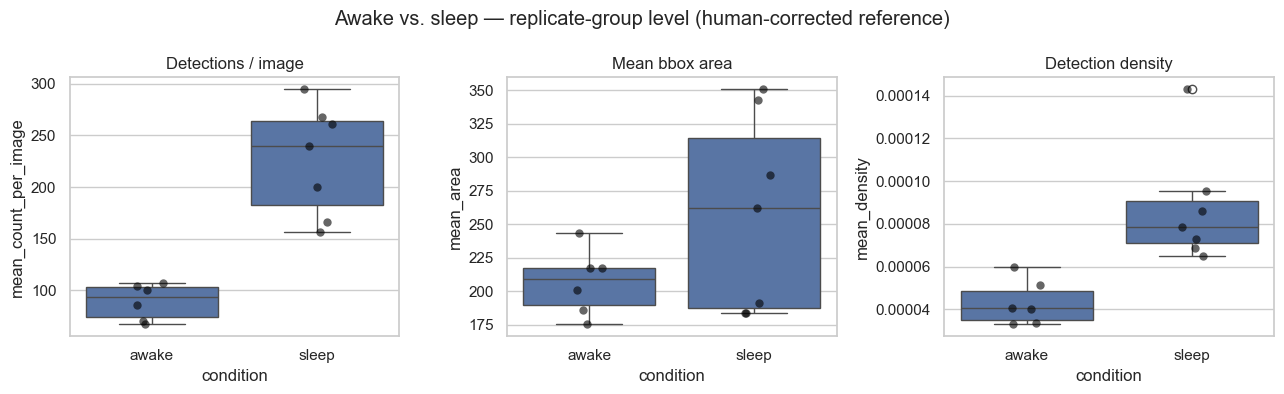

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(
    axes,
    ["mean_count_per_image", "mean_area", "mean_density"],
    ["Detections / image", "Mean bbox area", "Detection density"],
):
    sns.boxplot(data=group_summary, x="condition", y=col, ax=ax)
    sns.stripplot(data=group_summary, x="condition", y=col, ax=ax,
                  color="black", alpha=0.6, size=6)
    ax.set_title(title)
fig.suptitle("Awake vs. sleep — replicate-group level (human-corrected reference)")
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "awake_vs_sleep_group_level.png", dpi=150)
plt.show()


## 8. Z-stack depth trends

Averaged in two steps to respect the same replicate-group structure: first collapse images within each recording to one value per Z-index, then average across recordings within each condition (mean ± SEM).


In [94]:
zdf = per_image.dropna(subset=["z_index"]).copy()
zdf["z_index"] = zdf["z_index"].astype(int)

group_z = (
    zdf.groupby(["condition", "replicate_group", "z_index"])
    .agg(mean_count=("n_detections", "mean"), mean_area=("mean_area", "mean"))
    .reset_index()
)


def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan


z_trend = (
    group_z.groupby(["condition", "z_index"])
    .agg(mean_count=("mean_count", "mean"), sem_count=("mean_count", sem),
         mean_area=("mean_area", "mean"), sem_area=("mean_area", sem))
    .reset_index()
)
z_trend.head()


,condition,z_index,mean_count,sem_count,mean_area,sem_area
0,awake,0,102.833333,15.085129,247.261309,41.773815
1,awake,1,96.166667,11.942687,247.516304,40.375601
2,awake,2,97.500000,10.359376,251.217237,42.546052
3,awake,3,98.666667,10.101705,257.162613,56.227784
4,awake,4,93.333333,6.988880,253.506536,50.277586


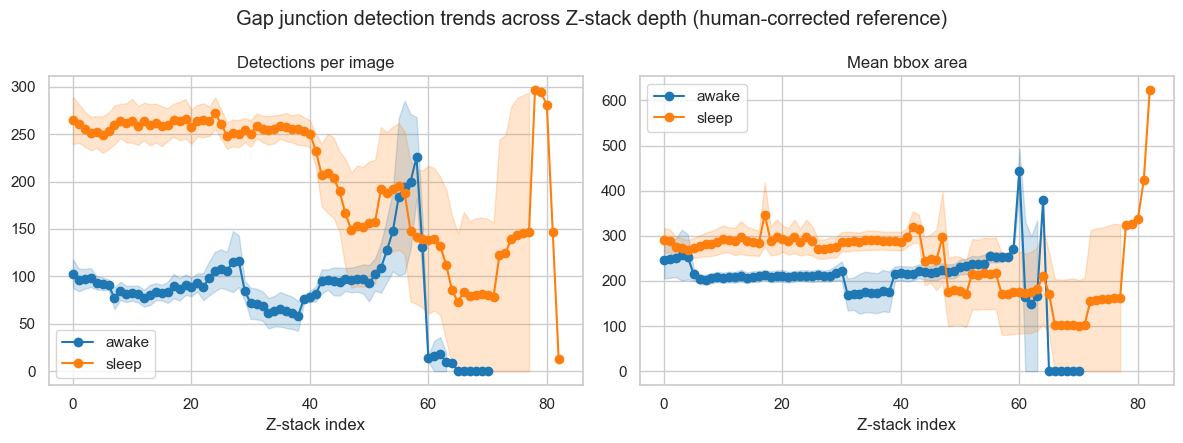

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"awake": "tab:blue", "sleep": "tab:orange"}
for ax, ycol, ecol, title in zip(
    axes, ["mean_count", "mean_area"], ["sem_count", "sem_area"],
    ["Detections per image", "Mean bbox area"],
):
    for condition, color in colors.items():
        sub = z_trend[z_trend.condition == condition].sort_values("z_index")
        ax.plot(sub.z_index, sub[ycol], label=condition, color=color, marker="o")
        ax.fill_between(sub.z_index, sub[ycol] - sub[ecol], sub[ycol] + sub[ecol],
                        color=color, alpha=0.2)
    ax.set_xlabel("Z-stack index")
    ax.set_title(title)
    ax.legend()
fig.suptitle("Gap junction detection trends across Z-stack depth (human-corrected reference)")
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "z_depth_trends.png", dpi=150)
plt.show()


## 9. Exploratory secondary check — per-image mixed-effects model

**Secondary/exploratory only.** This models every image as an observation with a random intercept per replicate group, which partially accounts for non-independence but does not replace the group-level Mann-Whitney test in Section 7 as the primary inferential result.


In [96]:
try:
    import statsmodels.formula.api as smf
    model = smf.mixedlm("n_detections ~ condition", data=per_image, groups=per_image["replicate_group"])
    result = model.fit()
    print(result.summary())
except ImportError:
    print("statsmodels not installed — skip this exploratory cell (pip install statsmodels to enable).")


             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  n_detections
No. Observations:    730      Method:              REML        
No. Groups:          13       Scale:               4127.4269   
Min. group size:     30       Log-Likelihood:      -4086.3228  
Max. group size:     83       Converged:           Yes         
Mean group size:     56.2                                      
---------------------------------------------------------------
                    Coef.   Std.Err.   z   P>|z| [0.025  0.975]
---------------------------------------------------------------
Intercept            89.002   16.866 5.277 0.000 55.947 122.058
condition[T.sleep]  137.338   22.958 5.982 0.000 92.342 182.335
Group Var          1621.803   11.304                           



## 10. Exports

All tidy tables and figures are written to `OUTPUT_DIR`.


In [97]:
# detections_df.to_csv(OUTPUT_DIR / "detections_long.csv", index=False)
# images_df.to_csv(OUTPUT_DIR / "images_inventory.csv", index=False)
# per_image.to_csv(OUTPUT_DIR / "per_image_summary.csv", index=False)
# group_summary.to_csv(OUTPUT_DIR / "per_replicate_group_summary.csv", index=False)
# detection_compare_df.to_csv(OUTPUT_DIR / "detection_source_agreement_per_image.csv", index=False)
# z_trend.to_csv(OUTPUT_DIR / "z_depth_trends.csv", index=False)

# print(f"Exports written to: {OUTPUT_DIR}")
# print(sorted(p.name for p in OUTPUT_DIR.iterdir()))


## 11. Recap — terminology & limitations

- **Section 6** (detection-source agreement) describes raw-model-vs-human-correction quality only. Do not cite its precision/recall/F1 numbers as evidence of an awake-sleep biological effect.
- **Sections 7–8** (awake vs. sleep) use the human-corrected reference exclusively, with the replicate group (one recording) as the statistical unit — 6 awake vs. 4 sleep groups, tested with Mann-Whitney U.
- In any Methods/Results/Discussion text drafted from these outputs, refer to the two sources only as **"raw model inference"** and **"human-corrected detections / reference"** — never by their session_* folder names.
- `sleep_2`, `sleep_2_1`, `sleep_2_2`, `sleep_2_3` are treated as **four separate** biological replicates (confirmed independent recordings, not chunks of one session) — giving 6 awake vs. 7 sleep groups overall.
